# 実行例の再現: トレッドミル歩行 6 秒間の direct collocation

トレッドミル歩行データに対する direct collocation の実行例と、その整合性確認・メッシュ密度の比較を再現するためのノートブックです。
対象は著者が撮影したトレッドミル歩行（ベルト速度 1.2 km/h）の記録 `treadmill_walk01` の $t = 2$〜$8$ s（6 秒間）です。

## パッケージ構成

```
execution_example/
  reproduce_example.ipynb   このノートブック（主）
  README.md                 概要と手順
  environment/              Dockerfile, 使用バージョン (versions.yaml), opencap-processing のコミット
  data/                     OpenCap の出力（セッションメタデータ, スケーリング済みモデル, 逆運動学 .mot, マーカー .trc）
  videos/                   解析区間に切り出した同期後の動画（2 台分, 360x640, 60 fps）
  scripts/                  前処理・実行・評価・作図スクリプト
  results/                  各実行の設定・ログ・出力（下表）
  figures/                  このノートブックが再生成した図
  runs/                     このパッケージで新たに実行した場合の出力先
```

| results/ の名前 | 内容 | 試行 | ベルト速度 | mesh | 窓 (s) |
|---|---|---|---|---|---|
| `main_mesh50` | 主の実行例（図と整合性確認の対象） | treadmill_walk01_pre | 0.333 m/s | 50 | 2–8 |
| `repeat_mesh50` | 同一設定の再実行 | 同上 | 同上 | 50 | 2–8 |
| `mesh25` / `mesh100` | メッシュ密度の比較 | 同上 | 同上 | 25 / 100 | 2–8 |
| `control_belt0` | 対照: ベルト速度 0 | 同上 | 0 | 50 | 2–6 |

## 再現の流れ

1. 入力データの確認とベルト速度・進行方向の推定（このノートブック内で実行、Docker 不要）
2. 逆運動学結果の前処理（同上。生成物が `data/OpenSimData/Kinematics/*_pre.mot` と一致することを確認）
3. OpenSimAD による最適化（Docker が必要。`RUN_DOCKER = True` にすると実行。1 本 2〜6 時間）
4. 結果の評価、メッシュ密度の比較、図の再生成（`results/` の出力を用いる。Docker 不要）


In [1]:
import os, io, re, glob, json, hashlib, subprocess
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
PKG = os.path.abspath('.')
DATA = os.path.join(PKG, 'data'); RES = os.path.join(PKG, 'results')
MASS_KG = 83.0; BW = MASS_KG * 9.81
BELT_M_S = 0.333          # トレッドミル表示値 1.2 km/h
WINDOW = (2.0, 8.0)       # 解析区間 (s)
MAIN = 'main_mesh50'; TRIAL = 'treadmill_walk01_pre'

def read_mot(path):
    lines = open(path, encoding='latin-1').read().splitlines()
    i = [k for k, l in enumerate(lines) if l.strip() == 'endheader'][0]
    df = pd.read_csv(io.StringIO('\n'.join(lines[i+1:])), sep='\t')
    return df[[c for c in df.columns if not c.startswith('Unnamed')]]

def read_trc(path):
    L = open(path, encoding='latin-1').read().splitlines(); hdr = L[3].split('\t')
    names = {h.strip(): k for k, h in enumerate(hdr) if h.strip() and k >= 2}
    rows = [l.split('\t') for l in L[6:] if l.strip()]
    arr = np.array([[float(x) if x.strip() else np.nan for x in r] for r in rows])
    return arr[:, 1], arr, names

def ipopt_stats(log):
    s = open(log, encoding='latin-1', errors='ignore').read()
    g = lambda pat: (re.findall(pat, s) or [None])[-1]
    d = {'iterations': g(r'Number of Iterations\.+:\s+(\d+)'), 'exit': g(r'EXIT: (.*)'),
         'solve_min': g(r'Solve: [\d.]+s \(([\d.]+) min\)'),
         'restoration_iters': len(re.findall(r'^\s*\d+r\s', s, flags=re.M)),
         'iter_lines': len(re.findall(r'^\s*\d+r?\s+[-\d.e+]+\s+[-\d.e+]+\s+[-\d.e+]+', s, flags=re.M))}
    for k, pat in [('objective', r'Objective\.+:\s+([-\d.e+]+)\s+([-\d.e+]+)'), ('dual_inf', r'Dual infeasibility\.+:\s+([-\d.e+]+)\s+([-\d.e+]+)'),
                   ('constr_viol', r'Constraint violation\.+:\s+([-\d.e+]+)\s+([-\d.e+]+)'), ('nlp_error', r'Overall NLP error\.+:\s+([-\d.e+]+)\s+([-\d.e+]+)')]:
        m = g(pat); d[k] = float(m[1]) if m else None   # unscaled
    d['iterations'] = int(d['iterations']) if d['iterations'] else None
    d['solve_min'] = float(d['solve_min']) if d['solve_min'] else None
    return d

def load_run(name):
    d = os.path.join(RES, name); out = os.path.join(d, 'outputs')
    st = yaml.safe_load(open(os.path.join(d, 'settings_full.yaml')))
    trial = [f for f in os.listdir(out) if f.startswith('kinematics_activations_')][0].replace('kinematics_activations_', '').replace(f'_{name}.mot', '')
    f = lambda kind: read_mot(os.path.join(out, f'{kind}_{trial}_{name}.mot'))
    return dict(name=name, trial=trial, settings=st, stats=ipopt_stats(os.path.join(d, 'stdout.log')),
                grfr=f('GRF_resultant'), grf=f('GRF'), kin=f('kinematics_activations'), kt=f('kinetics'))
print('パッケージ:', PKG)
print('利用できる実行結果:', sorted(os.listdir(RES)))

パッケージ: /work/execution_example
利用できる実行結果: ['control_belt0', 'main_mesh50', 'mesh100', 'mesh25', 'repeat_mesh50']


## 1. 入力データ

OpenCap のクラウド処理が出力したセッション一式のうち、再現に必要なものを `data/` に置いています。
- `sessionMetadata.yaml`: 被験者情報（身長・体重）、モデル、姿勢推定器（HRNet）
- `OpenSimData/Model/`: スケーリング済みモデル（接触球つきの `*_adjusted_contacts.osim` を OpenSimAD が使用）
- `OpenSimData/Kinematics/treadmill_walk01.mot`: クラウド処理の逆運動学結果（生データ）
- `MarkerData/treadmill_walk01.trc`: 3D キーポイントと拡張マーカー（ベルト速度・進行方向の推定に使用）
- `videos/`: 同期後動画（両カメラ、入力データと同じ 0〜10 s）

元の OpenCap セッションでは試行名が異なりますが、本パッケージでは `treadmill_walk01` に統一しています。

In [2]:
meta = yaml.safe_load(open(os.path.join(DATA, 'sessionMetadata.yaml')))
ik_raw = read_mot(os.path.join(DATA, 'OpenSimData/Kinematics/treadmill_walk01.mot'))
w = ik_raw[(ik_raw.time >= WINDOW[0]) & (ik_raw.time <= WINDOW[1])]
display(pd.Series({'身長 (m)': meta['height_m'], '体重 (kg)': meta['mass_kg'], 'モデル': meta['openSimModel'], '姿勢推定': meta['posemodel'], 'マーカー拡張': meta['augmentermodel'],
                   '逆運動学のフレーム数': len(ik_raw), 'サンプリング周波数 (Hz)': round(1 / np.median(np.diff(ik_raw.time)), 1), '時間範囲 (s)': '%.2f-%.2f' % (ik_raw.time.min(), ik_raw.time.max()), '座標数': ik_raw.shape[1] - 1,
                   '解析区間 (s)': '%.1f-%.1f' % WINDOW, '解析区間の pelvis_rotation 中央値 (度, 回転前)': round(float(w.pelvis_rotation.median()), 1), '解析区間の pelvis_ty 平均 (m)': round(float(w.pelvis_ty.mean()), 3)}).to_frame('値'))

,値
身長 (m),1.75
体重 (kg),83.0
モデル,LaiUhlrich2022
姿勢推定,hrnet
マーカー拡張,v0.3
逆運動学のフレーム数,601
サンプリング周波数 (Hz),60.0
時間範囲 (s),0.00-10.00
座標数,33
解析区間 (s),2.0-8.0


## 2. ベルト速度と進行方向の推定（マーカーから）

立脚期（踵・つま先キーポイントの高さが局所最小に近いフレーム）の水平速度の中央値をベルト速度の推定値とします。
解析では機器の表示値 1.2 km/h（0.333 m/s）を用いており、マーカー推定はその確認です。進行方向は両股関節キーポイントから求めます。

In [3]:
t, arr, names = read_trc(os.path.join(DATA, 'MarkerData/treadmill_walk01.trc'))
w = (t >= WINDOW[0]) & (t <= WINDOW[1])
R = arr[:, names['RHip']:names['RHip']+3]; Lh = arr[:, names['LHip']:names['LHip']+3]
fwd = np.cross(np.array([0, 1, 0]), R - Lh); heading = np.degrees(np.arctan2(-fwd[w, 2], fwd[w, 0]))
rows = {}
for n in ['RHeel', 'LHeel', 'LBigToe']:
    P = arr[:, names[n]:names[n]+3]; v = np.gradient(P, t, axis=0); y = P[:, 1]
    ymin = pd.Series(y).rolling(120, center=True, min_periods=10).min().values; st = w & (y < ymin + 0.03)
    vh = np.hypot(v[st, 0], v[st, 2])
    rows[n] = {'ベルト速度の推定 (m/s)': np.median(vh), '四分位範囲 下': np.percentile(vh, 25), '四分位範囲 上': np.percentile(vh, 75), 'vx (m/s)': np.median(v[st, 0]), 'vz (m/s)': np.median(v[st, 2])}
display(pd.DataFrame(rows).T.round(3))
print('回転前の進行方向の中央値 (度, 0 = +x): %.1f | 解析で用いた表示値: %.3f m/s' % (np.median(heading), BELT_M_S))

,ベルト速度の推定 (m/s),四分位範囲 下,四分位範囲 上,vx (m/s),vz (m/s)
RHeel,0.367,0.330,0.416,-0.003,-0.349
LHeel,0.359,0.331,0.396,-0.002,-0.356
LBigToe,0.372,0.342,0.409,0.004,-0.368


回転前の進行方向の中央値 (度, 0 = +x): -92.8 | 解析で用いた表示値: 0.333 m/s


## 3. 逆運動学結果の前処理

OpenSimAD のトレッドミルモデルは地面の $x$ 軸方向に動くため、進行方向が $+x$ になるよう骨盤の並進・回旋を鉛直軸まわりに $+90°$ 回転します。
OpenCap は記録内の最低点（この記録では冒頭の床面）を高さ 0 に取っているため、デッキ高さ分 0.19 m を骨盤鉛直位置から差し引きます。
距骨下関節角は可動域端（$\pm 35°$）に張り付いた区間が 6 Hz フィルタ後に可動域を超えるため、$\pm 33°$ に丸めます。
`scripts/preprocess_ik.py` を実行し、同梱の `treadmill_walk01_pre.mot` と一致することを確認します。

In [4]:
import shutil, tempfile
tmp = tempfile.mkdtemp(); shutil.copy(os.path.join(DATA, 'OpenSimData/Kinematics/treadmill_walk01.mot'), tmp)
subprocess.run(['python3', os.path.join(PKG, 'scripts/preprocess_ik.py'), tmp, 'treadmill_walk01', '--rot', '90', '--dy', '0.19', '--clip', '33', '--suffix', '_pre'], check=True, capture_output=True)
a = open(os.path.join(tmp, 'treadmill_walk01_pre.mot'), 'rb').read(); b = open(os.path.join(DATA, 'OpenSimData/Kinematics/treadmill_walk01_pre.mot'), 'rb').read()
ik = read_mot(os.path.join(DATA, 'OpenSimData/Kinematics/treadmill_walk01_pre.mot')); w = ik[(ik.time >= WINDOW[0]) & (ik.time <= WINDOW[1])]
raw = read_mot(os.path.join(DATA, 'OpenSimData/Kinematics/treadmill_walk01.mot')); wr = raw[(raw.time >= WINDOW[0]) & (raw.time <= WINDOW[1])]
clip = {c: int((np.abs(w[c].values - wr[c].values) > 0).sum()) for c in ['subtalar_angle_r', 'subtalar_angle_l']}
display(pd.Series({'再生成したファイルは同梱のものと一致': a == b, '前処理後の pelvis_rotation 中央値 (度)': round(float(w.pelvis_rotation.median()), 1), '前処理後の pelvis_ty 平均 (m)': round(float(w.pelvis_ty.mean()), 3),
                   '解析区間のフレーム数': len(w), '距骨下関節角の丸めを適用したフレーム数 右 / 左': '%d / %d' % (clip['subtalar_angle_r'], clip['subtalar_angle_l']),
                   '丸めによる角度変化の最大 (度)': round(float(max(np.abs(w[c].values - wr[c].values).max() for c in clip)), 2)}).to_frame('値'))

,値
再生成したファイルは同梱のものと一致,True
前処理後の pelvis_rotation 中央値 (度),-3.4
前処理後の pelvis_ty 平均 (m),1.012
解析区間のフレーム数,361
距骨下関節角の丸めを適用したフレーム数 右 / 左,27 / 0
丸めによる角度変化の最大 (度),2.0


## 4. OpenSimAD による最適化（Docker）

環境は `environment/Dockerfile` で構築します（`stanfordnmbl/opensim-python:4.5` を基に opencap-processing コミット `72b5416` を導入、CasADi 3.7.2、IPOPT 3.14.11、MUMPS）。

```bash
docker build -t bjscs-opencap-opensimad:m1-3 environment/
```

各実行は `scripts/run_docker.sh <run_name> <trial> <belt_speed_m_s> <mesh> <t0> <t1>` で起動します。出力は `runs/<run_name>/`（設定・ログ）と `data/OpenSimData/Dynamics/<trial>/`（.mot 等）に書かれます。
同一環境では再実行で決定変数まで完全に一致します（このノートブックの第 6 節）。実行時間の目安（8 コア割当、他の最適化と並列実行した場合）: mesh 50 で約 4 時間、mesh 100 で約 5.5 時間（メモリ約 37 GB）。

In [ ]:
RUN_DOCKER = False   # True にすると下の実行を順に行う（長時間を要します。）
RUNS = [('main_mesh50',   'treadmill_walk01_pre', 0.333, 50,  2, 8),
        ('repeat_mesh50', 'treadmill_walk01_pre', 0.333, 50,  2, 8),
        ('mesh25',        'treadmill_walk01_pre', 0.333, 25,  2, 8),
        ('mesh100',       'treadmill_walk01_pre', 0.333, 100, 2, 8),
        ('control_belt0', 'treadmill_walk01_pre', 0.0,   50,  2, 6)]
for r in RUNS:
    cmd = ['bash', os.path.join(PKG, 'scripts/run_docker.sh'), r[0], r[1], str(r[2]), str(r[3]), str(r[4]), str(r[5])]
    print(' '.join(cmd[1:]))
    if RUN_DOCKER: subprocess.run(cmd, check=True)

/work/execution_example/scripts/run_docker.sh main_mesh50 treadmill_walk01_pre 0.333 50 2 8
/work/execution_example/scripts/run_docker.sh repeat_mesh50 treadmill_walk01_pre 0.333 50 2 8
/work/execution_example/scripts/run_docker.sh mesh25 treadmill_walk01_pre 0.333 25 2 8
/work/execution_example/scripts/run_docker.sh mesh100 treadmill_walk01_pre 0.333 100 2 8
/work/execution_example/scripts/run_docker.sh control_belt0 treadmill_walk01_pre 0.0 50 2 6


## 5. 主例（`main_mesh50`）の評価

収束指標（IPOPT のログ）、床反力と体重の整合、立脚期の接触点速度とベルト速度の差（滑り）、逆運動学との追跡誤差、筋活動の飽和、周期ごとの立脚指標を求めます。整合性確認の条件 (i)(ii) の判定はここから得ています。

In [6]:
m = load_run(MAIN); st = m['stats']; g = m['grfr']; kin = m['kin']; kt = m['kt']; t = g.time.values
Rv, Lv = g.ground_force_right_vy.values, g.ground_force_left_vy.values; tot = Rv + Lv
# 荷重中の接触点速度とベルト速度の差
slip = {}
for side in 'rl':
    vs = []
    for k in range(1, 7):
        fy = m['grf'][[c for c in m['grf'].columns if f's{k}_{side}_vy' in c][0]].values; px = m['grf'][[c for c in m['grf'].columns if f's{k}_{side}_px' in c][0]].values
        sel = fy > 50
        if sel.sum() > 5: vs.append(np.gradient(px, t)[sel])
    slip[side] = float(np.median(np.concatenate(vs)) + BELT_M_S)
# 入力の逆運動学との追跡誤差 (RMS, 度)
ik = read_mot(os.path.join(DATA, f'OpenSimData/Kinematics/{TRIAL}.mot'))
tr = {j: float(np.sqrt(np.mean((np.interp(t, kin.time, kin[j]) - np.interp(t, ik.time, ik[j]))**2))) for j in ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r', 'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l']}
# 右踵接地から次の右踵接地までの整数周期での鉛直床反力の平均 (条件 (i))
on = Rv > 20; rs = []; s0 = None
for k in range(len(Rv)):
    if on[k] and s0 is None: s0 = k
    if ((not on[k]) or k == len(Rv) - 1) and s0 is not None: rs.append((t[s0], t[k])); s0 = None
full = [(a, b) for a, b in rs if b - a > 0.3]; a0, b0 = full[0][0], full[-1][0]; m_ = (t >= a0) & (t < b0)
summary = pd.Series({
    'IPOPT 終了状態': st['exit'], '反復回数': st['iterations'], '目的関数値': round(st['objective'], 4),
    '制約違反': '%.2e' % st['constr_viol'], '終了判定指標 (NLP 全体誤差)': '%.2e' % st['nlp_error'],
    '両足の鉛直床反力の和の時間平均 (BW)': round(tot.mean() / BW, 3),
    '整数周期 %.2f-%.2f s の鉛直床反力の平均 (BW)' % (a0, b0): round(tot[m_].mean() / BW, 3),
    '両脚支持の割合': round(float(((Rv > 20) & (Lv > 20)).mean()), 2),
    '接地点速度とベルト速度の差 右 / 左 (m/s)': '%+.3f / %+.3f' % (slip['r'], slip['l']),
    '追跡誤差 RMS の 6 関節角度の平均 (度)': round(float(np.mean(list(tr.values()))), 2),
    '追跡誤差 RMS の最大 (度)': '%s %.2f' % (max(tr, key=tr.get), max(tr.values())),
})
display(summary.to_frame('値'))
display(pd.Series(tr, name='追跡誤差 RMS (度)').round(2).to_frame())

,値
IPOPT 終了状態,Optimal Solution Found.
反復回数,2453
目的関数値,1.4276
制約違反,2.17e-06
終了判定指標 (NLP 全体誤差),3.93e-04
両足の鉛直床反力の和の時間平均 (BW),0.998
整数周期 2.32-6.84 s の鉛直床反力の平均 (BW),0.998
両脚支持の割合,0.34
接地点速度とベルト速度の差 右 / 左 (m/s),+0.010 / +0.006
追跡誤差 RMS の 6 関節角度の平均 (度),2.8


,追跡誤差 RMS (度)
hip_flexion_r,2.24
knee_angle_r,4.85
ankle_angle_r,1.76
hip_flexion_l,3.53
knee_angle_l,3.34
ankle_angle_l,1.08


## 6. 同一設定の再実行との一致

`repeat_mesh50` は `main_mesh50` と同一の設定・入力・Docker イメージで再実行したものです。反復数・目的関数値・決定変数ベクトル（`w_opt`）を比較します。

In [7]:
a = np.load(os.path.join(RES, MAIN, 'outputs', f'w_opt_{MAIN}.npy')); b = np.load(os.path.join(RES, 'repeat_mesh50', 'outputs', 'w_opt_repeat_mesh50.npy'))
s1, s2 = ipopt_stats(os.path.join(RES, MAIN, 'stdout.log')), ipopt_stats(os.path.join(RES, 'repeat_mesh50', 'stdout.log'))
display(pd.DataFrame({'反復回数': [s1['iterations'], s2['iterations']], '目的関数値': [s1['objective'], s2['objective']]}, index=[MAIN, 'repeat_mesh50']))
print('決定変数の数', a.size, '| 最大差', np.abs(a - b).max(), '| 完全一致', np.array_equal(a, b))

,反復回数,目的関数値
main_mesh50,2453,1.427635
repeat_mesh50,2453,1.427635


決定変数の数 348840 | 最大差 0.0 | 完全一致 True


## 7. メッシュ密度の比較

同一の入力・解析区間・設定でメッシュ密度のみを 25 / 50 / 100 に変えた結果です。主の実行例は OpenSimAD の例に倣って mesh 50 を用い、この水準で十分かを既定値 100 との比較で確かめます。比べる項目は次のとおりです。

1. IPOPT の終了条件（終了状態、制約違反、終了判定指標。許容値は OpenSimAD の歩行用既定値 $10^{-3}$）
2. 整合性確認の条件: (i) 右踵接地から次の右踵接地までの整数周期の区間における両足の鉛直床反力の和の時間平均が体重と一致すること（許容差は OpenCap の歩行の鉛直床反力の平均絶対誤差 8.2% BW）、(ii) 荷重中の足部がベルトに接する位置の速度がベルト速度と一致すること（許容差はベルト速度の表示値とマーカー推定値の差 0.03 m/s）
3. 逆運動学との追跡誤差: 左右の股関節屈曲・膝屈曲・足関節背屈の 6 つの関節角度の RMS の平均と最大。閾値は設けず、公開データの歩行の値 5.39°（`public_data/joint_angles.ipynb`）を入力の誤差の目安とする
4. 主要出力: 解析区間に全体が含まれる立脚期（右 2 歩・左 2 歩。踵接地と離地は鉛直床反力 20 N の閾値で定める）ごとの鉛直床反力のピーク、底屈モーメントの極小の値と時刻、ヒラメ筋のピーク時刻の範囲。参照値は公開データの計測値（`public_data/walking_kinetics.ipynb`、平均 ± 標準偏差）

目的関数値は追跡項と努力項の重み付き和で、小さい値が入力との整合を意味しないため判定には用いません。出力差は mesh 50 を基準に共通格子（100 Hz）で RMS と相関を求めます。

In [8]:
rows = []; ref = load_run(MAIN); tg = np.arange(WINDOW[0], WINDOW[1]-0.02, 0.01)
SIG = [('vGRF_R','grfr','ground_force_right_vy'),('vGRF_L','grfr','ground_force_left_vy'),('hip_r_moment','kt','hip_flexion_r_moment'),('knee_r_moment','kt','knee_angle_r_moment'),('ankle_r_moment','kt','ankle_angle_r_moment'),('soleus_r','kin','soleus_r/activation'),('gasmed_r','kin','gasmed_r/activation'),('glmed1_r','kin','glmed1_r/activation')]
for name in ['mesh25', MAIN, 'mesh100']:
    d = os.path.join(RES, name)
    if not os.path.isdir(d): print('ありません:', name); continue
    has_out = any(f.startswith('kinematics_activations_') for f in os.listdir(os.path.join(d, 'outputs')))
    if not has_out:   # 終了条件未達で停止: ログのみ
        s = ipopt_stats(os.path.join(d, 'stdout.log')); st = yaml.safe_load(open(os.path.join(d, 'settings_full.yaml')))
        note = open(os.path.join(d, 'NOTE.txt')).read().strip() if os.path.exists(os.path.join(d, 'NOTE.txt')) else ''
        rows.append(dict(run=name, mesh=st['meshDensity'], iterations=s['iter_lines'], objective=None, constr_viol=None, nlp_error=None, exit='終了条件未達で停止: ' + note)); continue
    r = load_run(name); s = r['stats']; ik = read_mot(os.path.join(DATA, f'OpenSimData/Kinematics/{r["trial"]}.mot'))
    row = dict(run=name, mesh=r['settings']['meshDensity'], iterations=s['iterations'], objective=s['objective'], constr_viol=s['constr_viol'], nlp_error=s['nlp_error'], exit=s['exit'])
    tot = (r['grfr'].ground_force_right_vy + r['grfr'].ground_force_left_vy)/BW; row['mean_vGRF_BW'] = float(tot.mean())
    tt = r['grfr'].time.values; row['knee_r_track_rms'] = float(np.sqrt(np.mean((np.interp(tt, r['kin'].time, r['kin'].knee_angle_r) - np.interp(tt, ik.time, ik.knee_angle_r))**2)))
    row['track_rms_mean6'] = float(np.mean([np.sqrt(np.mean((np.interp(tt, r['kin'].time, r['kin'][j]) - np.interp(tt, ik.time, ik[j]))**2)) for j in ['hip_flexion_r','knee_angle_r','ankle_angle_r','hip_flexion_l','knee_angle_l','ankle_angle_l']]))
    for lab, kind, col in SIG:
        y0 = np.interp(tg, ref[kind].time, ref[kind][col]); y = np.interp(tg, r[kind].time, r[kind][col])
        row[f'{lab}_rms_pct'] = float(100*np.sqrt(np.mean((y-y0)**2))/np.max(np.abs(y0))); row[f'{lab}_corr'] = float(np.corrcoef(y0, y)[0, 1])
    rows.append(row)
tab = pd.DataFrame(rows).set_index('run'); pd.set_option('display.width', 200)
display(tab[['mesh','iterations','objective','constr_viol','nlp_error','exit','mean_vGRF_BW','track_rms_mean6','knee_r_track_rms']].round(4))
display(tab[[c for c in tab.columns if c.endswith('_rms_pct') or c.endswith('_corr')]].round(2))

,mesh,iterations,objective,constr_viol,nlp_error,exit,mean_vGRF_BW,track_rms_mean6,knee_r_track_rms
run,,,,,,,,,
mesh25,25,3023,NaN,NaN,NaN,終了条件未達で停止: 3000 反復の時点で終了条件を満たさなかったため停止した (3020...,NaN,NaN,NaN
main_mesh50,50,2453,1.4276,0.0,0.0004,Optimal Solution Found.,0.9978,2.7996,4.8522
mesh100,100,2211,1.2393,0.0,0.0007,Optimal Solution Found.,0.9901,3.5173,7.9875


,vGRF_R_rms_pct,vGRF_R_corr,vGRF_L_rms_pct,vGRF_L_corr,hip_r_moment_rms_pct,hip_r_moment_corr,knee_r_moment_rms_pct,knee_r_moment_corr,ankle_r_moment_rms_pct,ankle_r_moment_corr,soleus_r_rms_pct,soleus_r_corr,gasmed_r_rms_pct,gasmed_r_corr,glmed1_r_rms_pct,glmed1_r_corr
run,,,,,,,,,,,,,,,,
mesh25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_mesh50,0.00,1.00,0.00,1.0,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00
mesh100,17.47,0.91,18.52,0.9,12.75,0.85,19.32,0.68,19.58,0.75,14.33,0.77,12.46,0.77,17.72,0.92


### 整合性確認と主要出力の表

歩行周期の事象は、歩行分析で標準とされるフォースプレートの閾値法（Zeni et al. (2008, Gait & Posture 27: 710–714)）に倣い、接触モデルの鉛直床反力で定めます: 踵接地 = 鉛直床反力が 20 N を上回った最初の時刻、離地 = その後 20 N を下回った最初の時刻、立脚期 = 踵接地から離地まで。閾値の 20 N は同文献がトレッドミル歩行で用いた値です。0.3 s 未満の短い接触（遊脚中の一時的な接触）は事象に数えません。公開データ（`public_data/walking_kinetics.ipynb`）も同じ閾値です。
条件 (i) の鉛直床反力の周期平均（右踵接地から右踵接地までの 2 周期）、立脚期ごとの主要出力の範囲、および公開データの参照値（平均 ± 標準偏差を範囲で表示）を並べて示します。

In [9]:
THR_N = 20.0   # 接地判定の閾値 (N)
def heel_strikes(f, t, thr=THR_N, min_len=0.3):
    # 鉛直床反力が閾値を超えた時刻のうち、min_len 秒以上接地が続くもの（遊脚中の短い接触を除く）
    dt = np.median(np.diff(t)); k_min = int(round(min_len / dt))
    return [k for k in range(1, len(f)) if f[k] > thr and f[k-1] <= thr and (f[k:k+k_min] > thr).all()]
def cycle_mean_vgrf(run, n_cycles=2):
    r = load_run(run); g = r['grfr']; t = g.time.values; R_, L_ = g.ground_force_right_vy.values, g.ground_force_left_vy.values
    hs = heel_strikes(R_, t); a, b = hs[0], hs[n_cycles]; m = (t >= t[a]) & (t < t[b])
    return (R_[m] + L_[m]).mean() / BW, (t[a] - t[0], t[b] - t[0])
def stances(run, thr=THR_N, min_len=0.3):
    r = load_run(run); g = r['grfr']; t = g.time.values; out = []
    for side, S in [('r', 'right'), ('l', 'left')]:
        f = g[f'ground_force_{S}_vy'].values; idx = np.where(f > thr)[0]
        for seg in np.split(idx, np.where(np.diff(idx) > 1)[0] + 1):
            i0, i1 = seg[0], seg[-1] + 1   # i0: 踵接地 (閾値を上回った最初のフレーム), i1: 離地 (その後閾値を下回った最初のフレーム)
            if i0 == 0 or i1 > len(t) - 1 or t[i1] - t[i0] < min_len: continue   # 解析区間に全体が含まれる立脚期のみ
            ts, te = t[i0], t[i1]; m = (t >= ts) & (t < te); pct = lambda j: 100 * (t[j] - ts) / (te - ts)
            am = np.interp(t, r['kt'].time, r['kt'][f'ankle_angle_{side}_moment']); j = np.argmin(np.where(m, am, 1e9))
            sol = np.interp(t, r['kin'].time, r['kin'][f'soleus_{side}/activation']); k = np.argmax(np.where(m, sol, -1e9))
            out.append(dict(run=run, side=side, t0=ts - t[0], t1=te - t[0], vgrf_peak_bw=100 * f[m].max() / BW, ankle_min_nm=am[j], ankle_min_pct=pct(j), soleus_peak_pct=pct(k)))
    return pd.DataFrame(out)
runs = [n for n in [MAIN, 'mesh100'] if os.path.isdir(os.path.join(RES, n, 'outputs')) and any(f.startswith('GRF_resultant') for f in os.listdir(os.path.join(RES, n, 'outputs')))]
ST = pd.concat([stances(n) for n in runs]); display(ST.round(1))
# 公開データの参照値（public_data/walking_kinetics.ipynb の要約表）
ref_csv = os.path.join(PKG, '..', 'public_data', 'results', 'walking_kinetics_summary.csv')
REF = pd.read_csv(ref_csv, index_col=0) if os.path.exists(ref_csv) else None
# 参照値の範囲は小数第 0 位に丸めた平均 ± 標準偏差
rng = lambda k: ('%.0f〜%.0f' % (round(REF.loc[k, 'mean']) - round(REF.loc[k, 'sd']), round(REF.loc[k, 'mean']) + round(REF.loc[k, 'sd']))) if REF is not None else '---'
fmt = lambda s: '%.0f〜%.0f' % (s.min(), s.max())
rows = {'鉛直床反力の周期平均 (BW)': {n: '%.3f' % cycle_mean_vgrf(n)[0] for n in runs} | {'参照値': '0.918〜1.082'},
        '鉛直床反力のピーク (% BW)': {n: fmt(ST[ST.run == n].vgrf_peak_bw) for n in runs} | {'参照値': rng('vgrf_peak_ref_bw')},
        '底屈モーメントの極小の値 (Nm)': {n: fmt(ST[ST.run == n].ankle_min_nm) for n in runs} | {'参照値': rng('ankle_min_ref_nm')},
        '底屈モーメントの極小の時刻 (立脚期の %)': {n: fmt(ST[ST.run == n].ankle_min_pct) for n in runs} | {'参照値': rng('ankle_min_pct_ref')},
        'ヒラメ筋のピーク時刻 (立脚期の %)': {n: fmt(ST[ST.run == n].soleus_peak_pct) for n in runs} | {'参照値': rng('soleus_peak_pct_emg')}}
display(pd.DataFrame(rows).T)


,run,side,t0,t1,vgrf_peak_bw,ankle_min_nm,ankle_min_pct,soleus_peak_pct
0,main_mesh50,r,0.3,1.6,105.7,-118.2,85.9,84.4
1,main_mesh50,r,2.6,3.9,109.4,-133.3,88.4,89.9
2,main_mesh50,l,1.2,2.9,117.7,-109.4,81.6,81.6
3,main_mesh50,l,3.8,5.1,111.6,-111.4,74.6,69.8
0,mesh100,r,0.3,1.6,108.4,-114.2,84.4,85.2
1,mesh100,r,2.6,4.4,118.0,-128.9,68.0,68.0
2,mesh100,l,1.2,2.9,119.4,-120.3,84.4,85.0
3,mesh100,l,4.0,5.1,112.7,-118.7,71.6,74.5


,main_mesh50,mesh100,参照値
鉛直床反力の周期平均 (BW),0.998,0.996,0.918〜1.082
鉛直床反力のピーク (% BW),106〜118,108〜119,105〜115
底屈モーメントの極小の値 (Nm),-133〜-109,-129〜-114,-111〜-71
底屈モーメントの極小の時刻 (立脚期の %),75〜88,68〜84,74〜76
ヒラメ筋のピーク時刻 (立脚期の %),70〜90,68〜85,78〜88


## 8. 対照実験（ベルト速度 0）

- `control_belt0`: 同じ記録の 2〜6 s をベルト速度 0（地上歩行の扱い）で解いたもの。形式上は終了条件を満たすが、荷重中の足を静止地面に止めた解になり、追跡誤差が膝で 27〜30°、鉛直床反力のピークが 2.4〜2.6 BW、目的関数値が主例の 19 倍になります。収束ステータスだけでは解の妥当性を判断できないことの例です。

In [10]:
d = os.path.join(RES, 'control_belt0'); s = ipopt_stats(os.path.join(d, 'stdout.log')); r = load_run('control_belt0')
ik = read_mot(os.path.join(DATA, f'OpenSimData/Kinematics/{TRIAL}.mot')); tt = r['grfr'].time.values
tr_c = {j: float(np.sqrt(np.mean((np.interp(tt, r['kin'].time, r['kin'][j]) - np.interp(tt, ik.time, ik[j]))**2))) for j in ['knee_angle_r', 'knee_angle_l']}
display(pd.Series({'IPOPT 終了状態': s['exit'], '反復回数': s['iterations'], '目的関数値': round(s['objective'], 3), '制約違反': '%.2e' % s['constr_viol'],
                   '両足の鉛直床反力の和の時間平均 (BW)': round(float((r['grfr'].ground_force_right_vy + r['grfr'].ground_force_left_vy).mean() / BW), 3),
                   '鉛直床反力のピーク 右 / 左 (BW)': '%.2f / %.2f' % (r['grfr'].ground_force_right_vy.max() / BW, r['grfr'].ground_force_left_vy.max() / BW),
                   '膝の追跡誤差 RMS 右 / 左 (度)': '%.1f / %.1f' % (tr_c['knee_angle_r'], tr_c['knee_angle_l'])}).to_frame('control_belt0'))

,control_belt0
IPOPT 終了状態,Optimal Solution Found.
反復回数,1754
目的関数値,26.745
制約違反,1.76e-06
両足の鉛直床反力の和の時間平均 (BW),1.0
鉛直床反力のピーク 右 / 左 (BW),2.57 / 2.36
膝の追跡誤差 RMS 右 / 左 (度),27.5 / 30.2


## 9. 図の再生成

図は `scripts/make_paper_figs.py`（床反力・関節モーメント・筋活動・ヒラメ筋、`results/main_mesh50` の出力から）と `scripts/make_mesh_overlay.py`（mesh 50 と 100 の重ね描き。灰色の帯は入力の接地が接触モデルの前提を満たさない 3.8〜4.4 s）で生成します。ここでは同じスクリプトを呼び出して `figures/` に書き出し、PNG を表示します。

床反力


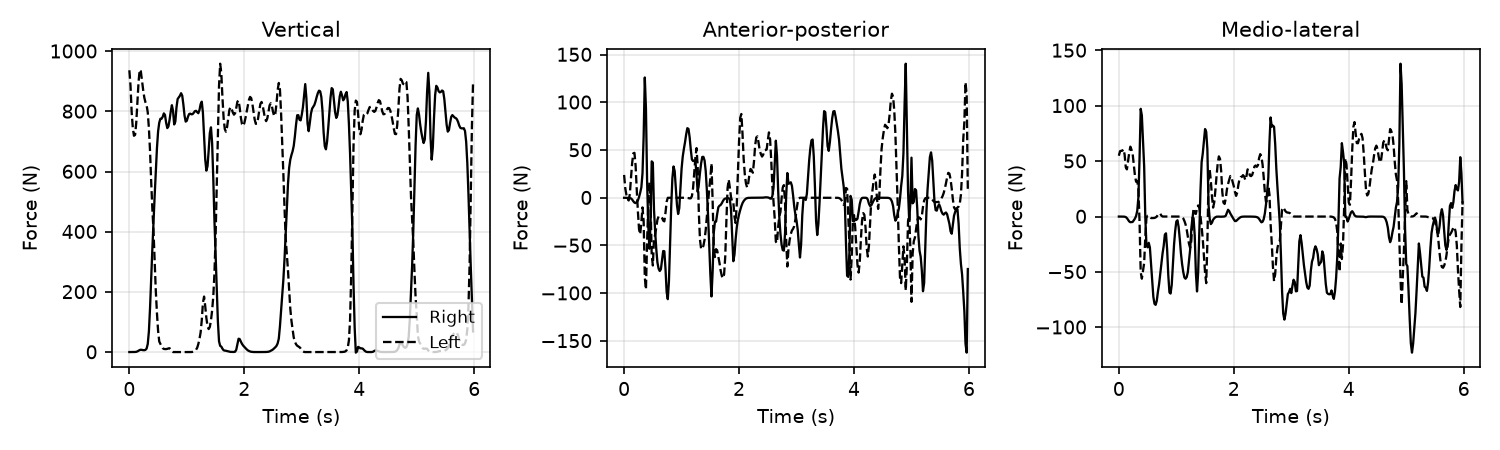

関節モーメント


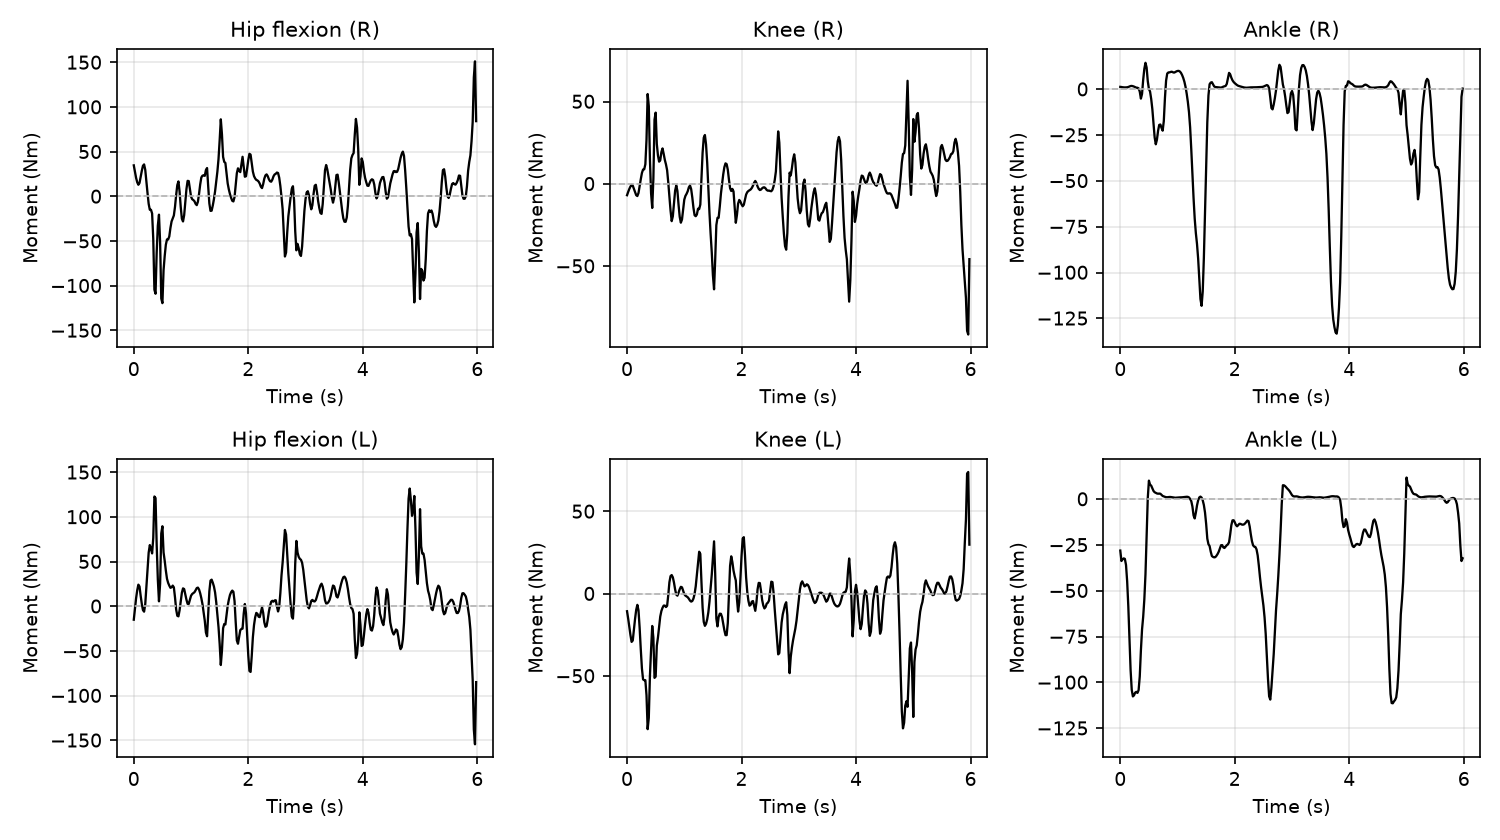

筋活動


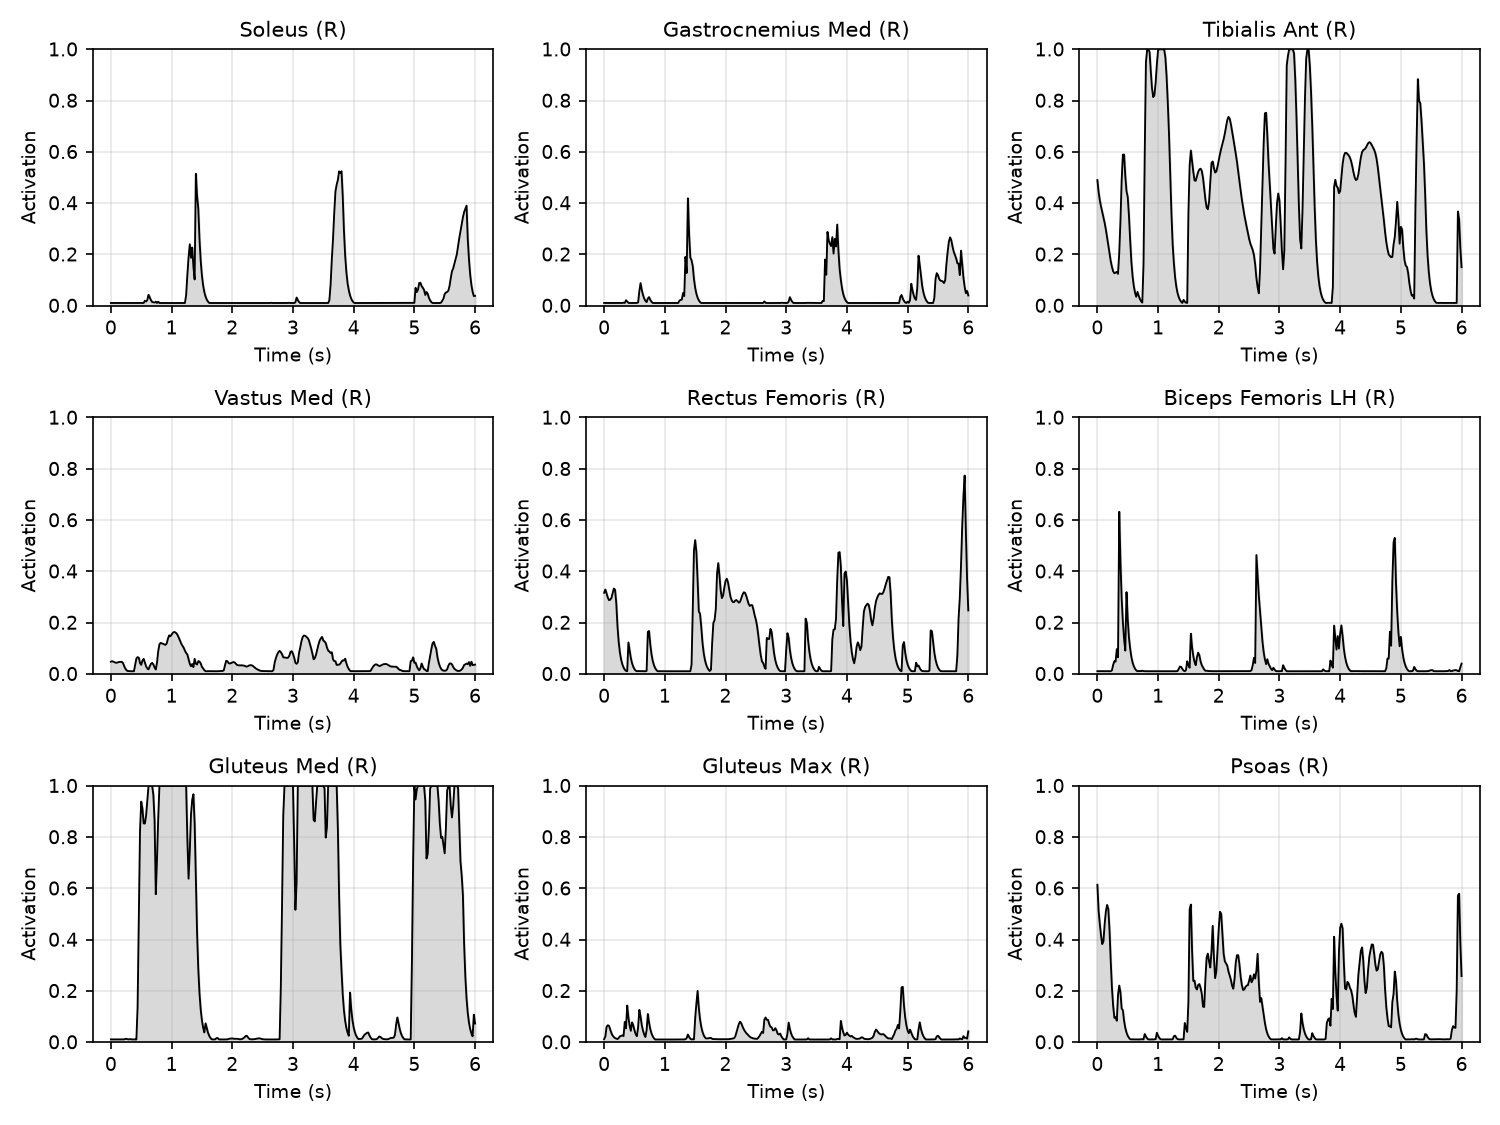

ヒラメ筋


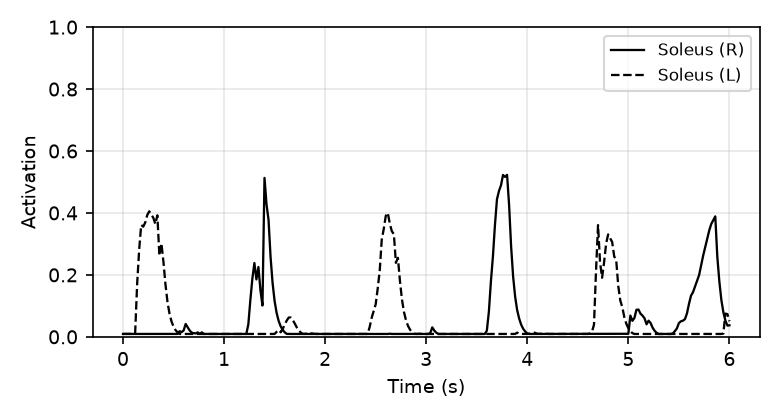

mesh 50 と 100


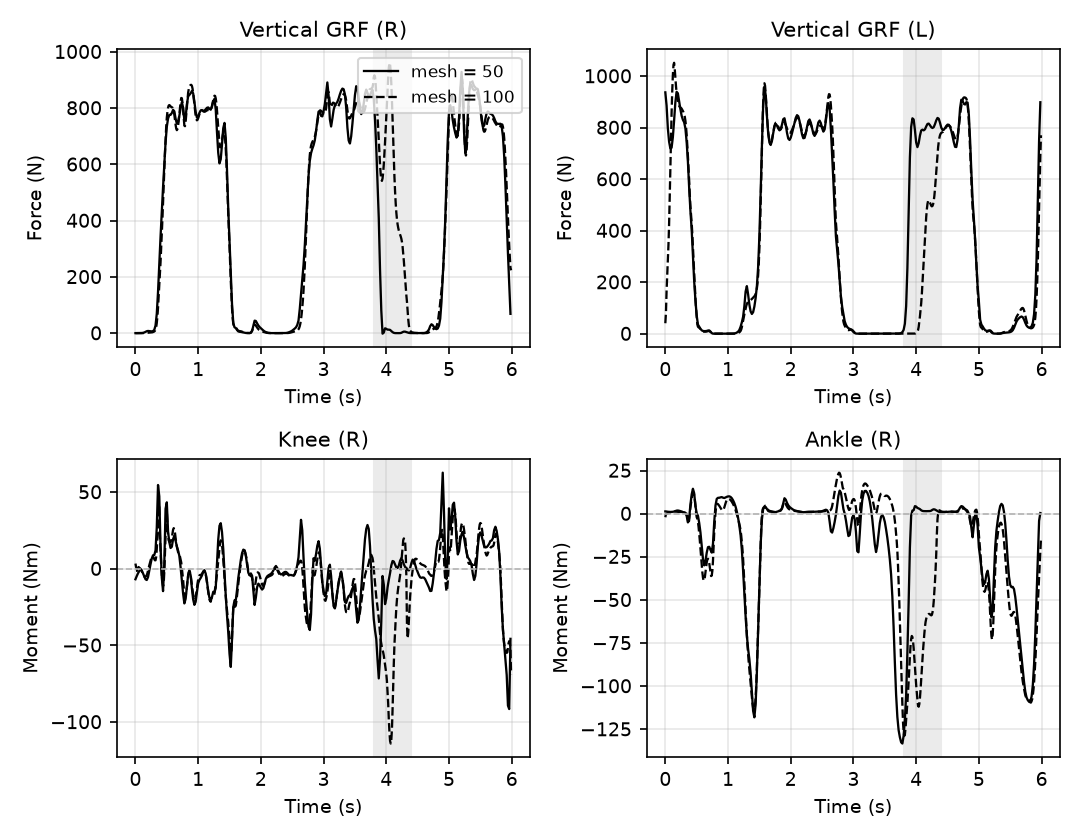

In [11]:
from IPython.display import Image, display
for cmd in [['python3', 'scripts/make_paper_figs.py', MAIN, 'figures', 'main', 'rel'], ['python3', 'scripts/make_mesh_overlay.py', MAIN, 'mesh100', 'figures', '50_100', '--shade', '3.8', '4.4', '--compact']]:
    subprocess.run(cmd, check=True, capture_output=True, cwd=PKG)
for f, cap in [('fig_grf_main', '床反力'), ('fig_joint_moments_main', '関節モーメント'), ('fig_muscle_activations_main', '筋活動'), ('fig_soleus_main', 'ヒラメ筋'), ('fig_mesh_overlay_50_100', 'mesh 50 と 100')]:
    print(cap); display(Image(filename=os.path.join(PKG, 'figures', f + '.png'), width=720))

## 10. ファイルの完全性（MANIFEST.sha256）

`MANIFEST.sha256` に `data/`, `results/`, `videos/`, `scripts/`, `environment/`, `README.md` の SHA-256 を記録しています（このノートブック自身と `figures/` は対象外）。

In [12]:
man = os.path.join(PKG, 'MANIFEST.sha256')
if os.path.exists(man):
    bad = 0; n = 0
    for line in open(man):
        h, path = line.strip().split('  ', 1); n += 1
        if hashlib.sha256(open(os.path.join(PKG, path), 'rb').read()).hexdigest() != h: bad += 1; print('MISMATCH:', path)
    print('照合したファイル %d 件, 不一致 %d 件' % (n, bad))
else: print('MANIFEST.sha256 がありません')

照合したファイル 187 件, 不一致 0 件
